# 04 — Mean-Reversion Alpha Sweep

Test mean-reversion (contrarian) templates across fields and windows.

## Reversion intuition

Mean-reversion alphas bet that stocks which have moved too far in one direction
will snap back. In Brain:

- `-ts_zscore(close, 5)` — short stocks that are unusually high vs their recent mean, long laggards
- `ts_mean(close, 10) - close` — buy stocks trading below their 10-day average
- `-ts_rank(returns, 3)` — fade the last 3 days of momentum (very short-term reversion)

Reversion alphas tend to have **higher turnover** than momentum (shorter holding periods).
Watch the `fitness` formula — high turnover penalises fitness.

## Key settings for reversion

- Use short windows: 3, 5, 10 days
- `decay=0` — no smoothing, you want the raw reversion signal
- `truncation=0.05–0.08` to keep individual position sizes reasonable
- Consider `TOP1000` universe (large-caps) where reversion is stronger

In [1]:
import sys
from pathlib import Path
import pandas as pd
from tqdm.notebook import tqdm

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from wq.client import get_client, simulate
from wq.alpha import AlphaConfig, reversion_alphas, REVERSION_TEMPLATES, expand_templates
from wq.utils import load_results, top_alphas, parse_result

client = get_client()

Authenticated as jayesh.s@alumni.iitgn.ac.in


In [2]:
FIELDS = ['close', 'returns', 'vwap', 'open']
WINDOWS = [3, 5, 10]
LONG_WINDOW = 20

SIM_SETTINGS = dict(
    universe='TOP3000',
    region='USA',
    neutralization='Subindustry',
    delay=1,
    decay=0,
)

all_configs = []
for field in FIELDS:
    for window in WINDOWS:
        for expr in expand_templates(REVERSION_TEMPLATES, field, window=window, long_window=LONG_WINDOW):
            all_configs.append(AlphaConfig(
                expression=expr,
                tags=['reversion', field, f'w{window}'],
                notes=f'Reversion sweep: {field}, window={window}',
                **SIM_SETTINGS,
            ))

print(f'Total reversion alphas to test: {len(all_configs)}')

Total reversion alphas to test: 48


In [3]:
# Skip already-run fingerprints
existing = load_results()
done_fingerprints = set(existing['fingerprint'].dropna()) if not existing.empty else set()
to_run = [c for c in all_configs if c.fingerprint() not in done_fingerprints]
print(f'{len(to_run)} to run, {len(done_fingerprints)} already done')

48 to run, 47 already done


In [4]:
for config in tqdm(to_run, desc='Reversion sweep'):
    try:
        result = simulate(client, config, save=True)
        m = parse_result(result)
        print(f'  sharpe={m["is_sharpe"]}  turnover={m["is_turnover"]}  {config.expression[:60]}')
    except Exception as e:
        print(f'  ERROR: {e}')

Reversion sweep:   0%|          | 0/48 [00:00<?, ?it/s]

Submitting: -1 * ts_zscore(close, 3)
  sim_id=45OybBbm14gJ9Ug6418dVNz — polling every 10s...
  status=COMPLETE
  sharpe=1.95  turnover=1.2499  -1 * ts_zscore(close, 3)
Submitting: ts_mean(close, 3) - close
  sim_id=2z47NQdaO4hj8W71c2Xpmg43 — polling every 10s...
  status=COMPLETE
  sharpe=1.17  turnover=1.075  ts_mean(close, 3) - close
Submitting: -1 * ts_rank(close, 3)
  sim_id=YZ6DreRD5268BQXaCwawRA — polling every 10s...
  status=COMPLETE
  sharpe=1.87  turnover=1.2148  -1 * ts_rank(close, 3)
Submitting: ts_mean(close, 20) - ts_mean(close, 3)
  sim_id=3Yy1OAbKa4CU8CU17AztPW15 — polling every 10s...
  status=COMPLETE
  sharpe=1.2  turnover=0.2356  ts_mean(close, 20) - ts_mean(close, 3)
Submitting: -1 * ts_zscore(close, 5)
  sim_id=44zHiYb4Z4iO8V81gdzUi2hI — polling every 10s...
  status=COMPLETE
  sharpe=2.0  turnover=0.9542  -1 * ts_zscore(close, 5)
Submitting: ts_mean(close, 5) - close
  sim_id=4rso8WXA4SGcfnas0hyDWr — polling every 10s...
  status=COMPLETE
  sharpe=1.08  turnover=

## Analysis

44 reversion results


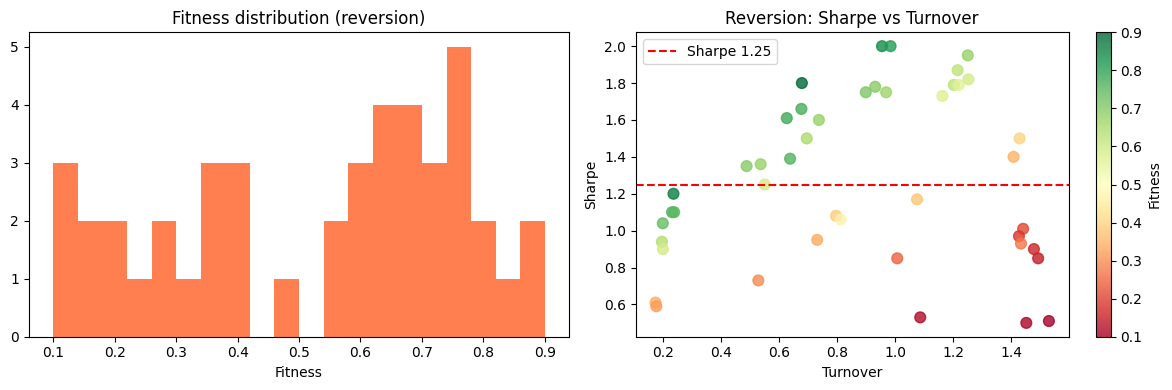

In [5]:
import matplotlib.pyplot as plt

all_results = load_results()
rev_results = all_results[all_results['tags'].str.contains('reversion', na=False)].copy()
rev_results = rev_results.dropna(subset=['is_sharpe', 'is_fitness'])

print(f'{len(rev_results)} reversion results')

if len(rev_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Fitness distribution
    axes[0].hist(rev_results['is_fitness'].dropna(), bins=20, color='coral')
    axes[0].set_title('Fitness distribution (reversion)')
    axes[0].set_xlabel('Fitness')

    # Sharpe vs Turnover
    sc = axes[1].scatter(
        rev_results['is_turnover'], rev_results['is_sharpe'],
        c=rev_results['is_fitness'], cmap='RdYlGn', s=60, alpha=0.8
    )
    plt.colorbar(sc, ax=axes[1], label='Fitness')
    axes[1].axhline(1.25, color='red', linestyle='--', label='Sharpe 1.25')
    axes[1].set_xlabel('Turnover')
    axes[1].set_ylabel('Sharpe')
    axes[1].set_title('Reversion: Sharpe vs Turnover')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [6]:
# Best reversion alphas
top_alphas(rev_results, n=10)[['expression', 'is_sharpe', 'is_fitness', 'is_returns', 'is_turnover']]

,expression,is_sharpe,is_fitness,is_returns,is_turnover
0,"-1 * ts_zscore(close, 10)",1.80,0.90,0.1679,0.6781
1,"ts_mean(close, 20) - ts_mean(close, 3)",1.20,0.86,0.1203,0.2356
2,"-1 * ts_zscore(close, 5)",2.00,0.84,0.1693,0.9542
3,"-1 * ts_rank(close, 5)",2.00,0.81,0.1607,0.9838
4,"-1 * ts_zscore(vwap, 10)",1.61,0.78,0.1485,0.6261
5,"-1 * ts_rank(vwap, 10)",1.66,0.77,0.1462,0.6765
6,"ts_mean(returns, 20) - ts_mean(returns, 5)",1.39,0.76,0.1929,0.6376
7,"ts_mean(vwap, 20) - ts_mean(vwap, 3)",1.10,0.76,0.1098,0.2307
8,"ts_mean(open, 20) - ts_mean(open, 3)",1.10,0.75,0.1108,0.2380
9,"ts_mean(close, 20) - ts_mean(close, 5)",1.04,0.74,0.1011,0.1988
